In [1]:
import pandas as pd


In [2]:
import numpy as np


In [3]:
df = pd.read_csv(r"C:\Users\hi\OneDrive\Documents\Working\dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop("customerID", axis=1, inplace=True)

In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [12]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

C:\Users\hi\AppData\Local\Temp\ipykernel_12672\575980950.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred = model.predict(X_test)

In [21]:
print(y_pred)

[1 0 0 ... 0 0 1]


In [22]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [23]:
accuracy = accuracy_score(y_test, y_pred)

In [24]:
print("Accuracy:", accuracy*100)

Accuracy: 79.55997161107167


In [25]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



In [26]:
cm = confusion_matrix(
    y_test,
    y_pred
)

In [27]:
import matplotlib.pyplot as plt

In [28]:
import seaborn as sns

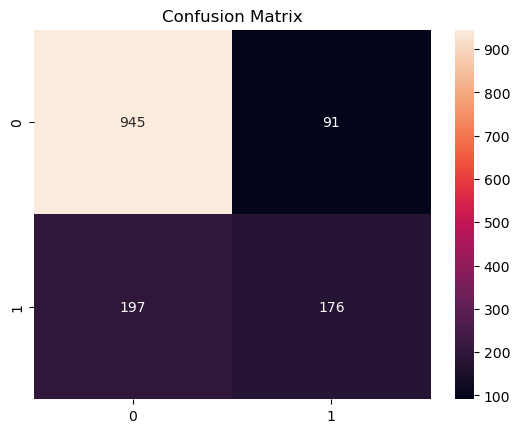

In [29]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

In [31]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

            Feature  Importance
18     TotalCharges    0.189992
17   MonthlyCharges    0.177867
4            tenure    0.157428
14         Contract    0.077357
16    PaymentMethod    0.050379
8    OnlineSecurity    0.047432
11      TechSupport    0.044190
0            gender    0.028117
9      OnlineBackup    0.027067
7   InternetService    0.026444


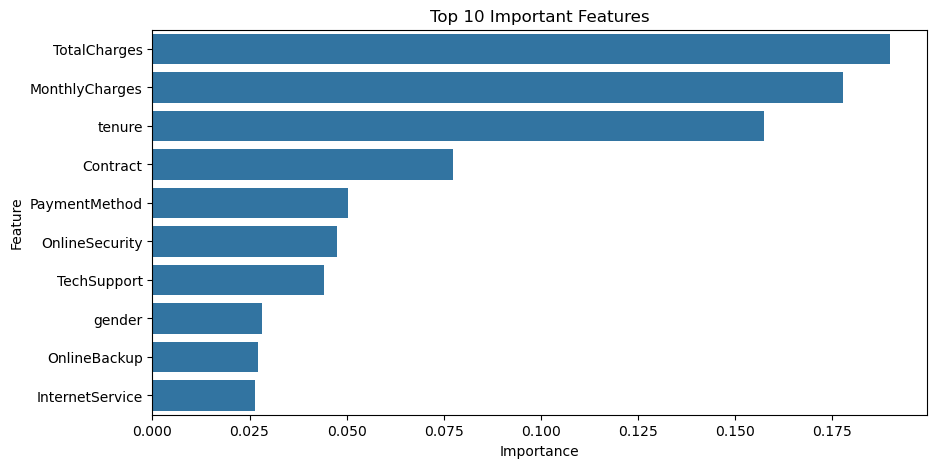

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [33]:
sample = X_test.iloc[[0]]

In [34]:
prediction = model.predict(sample)

In [35]:
if prediction[0] == 1:
    print("Customer likely to Churn")
else:
    print("Customer likely to Stay")

Customer likely to Churn


In [36]:
import pickle

In [37]:
import joblib
joblib.dump(model, "churn_model.pkl")


['churn_model.pkl']